# 1. Inspecting the dataset structure and variables

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('hotel_bookings.csv')

# Display the first 5 rows to confirm it's loaded correctly
print("\n--- Dataset Head ---")
display(df.head())


--- Dataset Head ---


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
print("--- Data Structure Info ---")
print(df.info())

print("\n--- Specific Data Types ---")
print(df[['children', 'agent', 'company', 'adr']].dtypes)

print("\n--- Key Columns Summary ---")
key_columns_summary = {
    'is_canceled': 'Binary indicator (1 if canceled, 0 otherwise)',
    'lead_time': 'Number of days between booking and arrival',
    'adr': 'Average Daily Rate (Price per room per night)',
    'total_of_special_requests': 'Number of special requests made by the guest',
    'hotel': 'Type of hotel (City or Resort)'
}
for col, desc in key_columns_summary.items():
    print(f"{col}: {desc}")

--- Data Structure Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  i

# 2. Checking missing values and outliers

--- Missing Values per Column ---
children         4
country        488
agent        16340
company     112593
dtype: int64


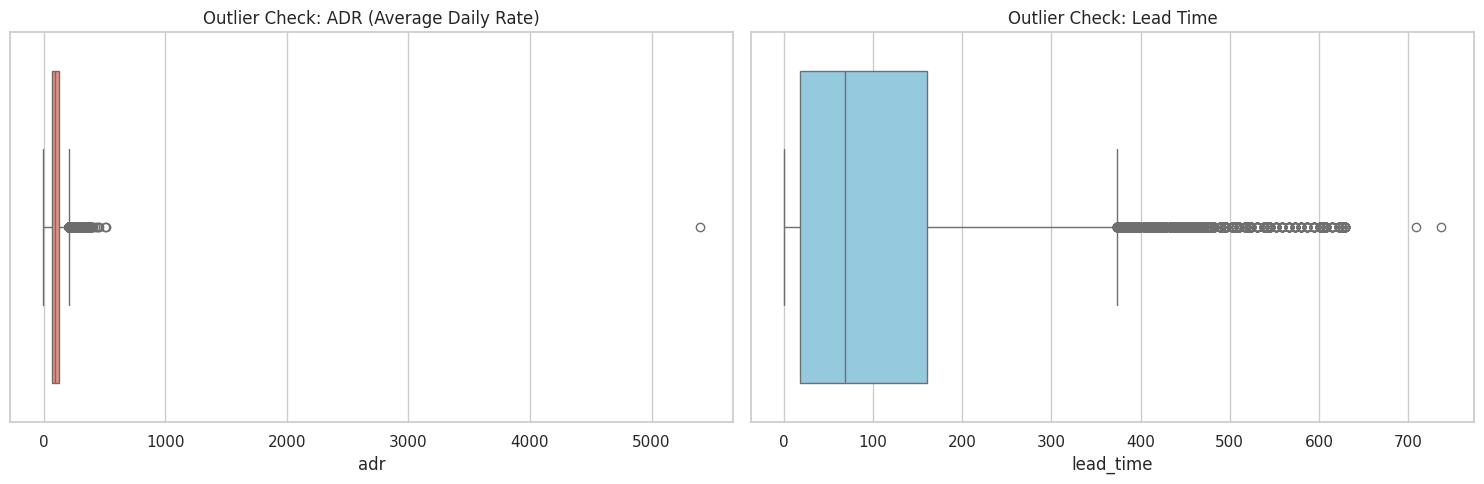

In [ ]:
# Check for missing values
missing_data = df.isnull().sum()
print("--- Missing Values per Column ---")
print(missing_data[missing_data > 0])

# Visualize outliers using boxplots for key numerical columns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['adr'], ax=axes[0], color='salmon')
axes[0].set_title('Outlier Check: ADR (Average Daily Rate)')

sns.boxplot(x=df['lead_time'], ax=axes[1], color='skyblue')
axes[1].set_title('Outlier Check: Lead Time')

plt.tight_layout()
plt.show()

Missing values were identified in children, country, agent, and company. Outliers in adr and lead_time were also observed through boxplots

# 3. Exploring distributions

# 4. Creating visualizations



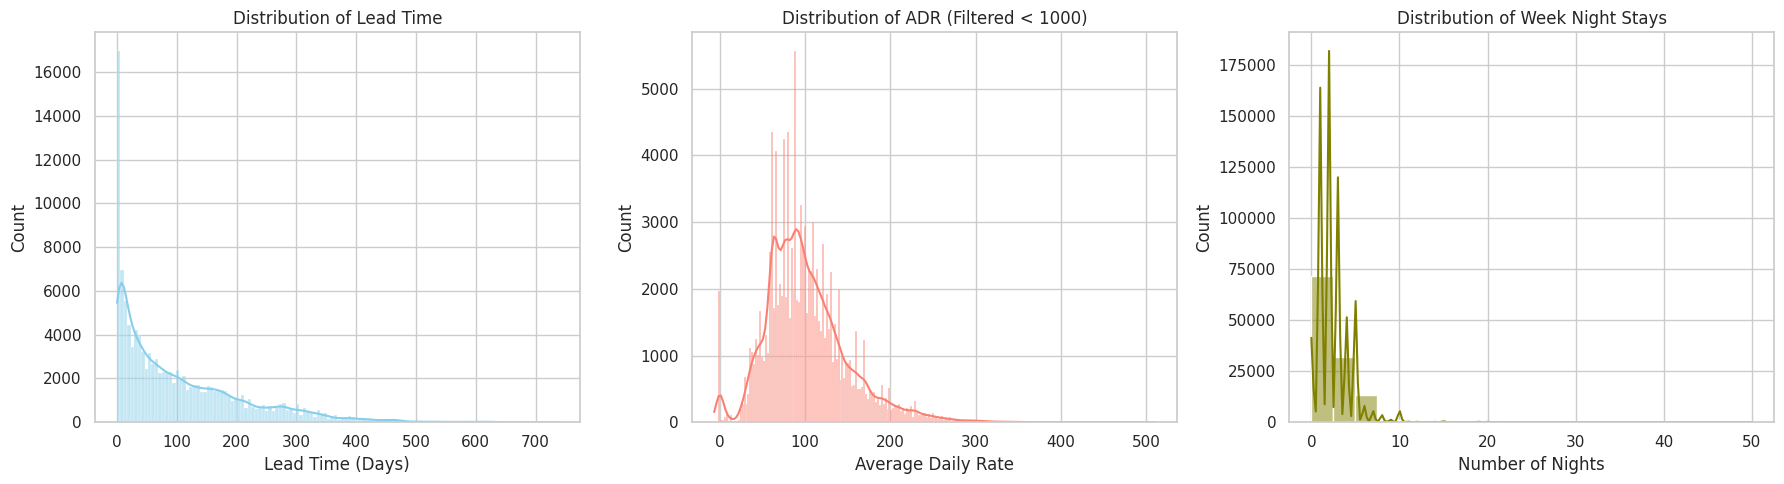

In [ ]:
# Set the visual style
sns.set_theme(style='whitegrid')

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot distribution of lead_time
sns.histplot(df['lead_time'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Lead Time')
axes[0].set_xlabel('Lead Time (Days)')

# Plot distribution of adr
# Note: We filter adr < 1000 for better visualization of the main distribution
sns.histplot(df[df['adr'] < 1000]['adr'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of ADR (Filtered < 1000)')
axes[1].set_xlabel('Average Daily Rate')

# Plot distribution of stays_in_week_nights
sns.histplot(df['stays_in_week_nights'], kde=True, ax=axes[2], color='olive', bins=20)
axes[2].set_title('Distribution of Week Night Stays')
axes[2].set_xlabel('Number of Nights')

# Adjust layout and show plots
plt.tight_layout()
plt.show()

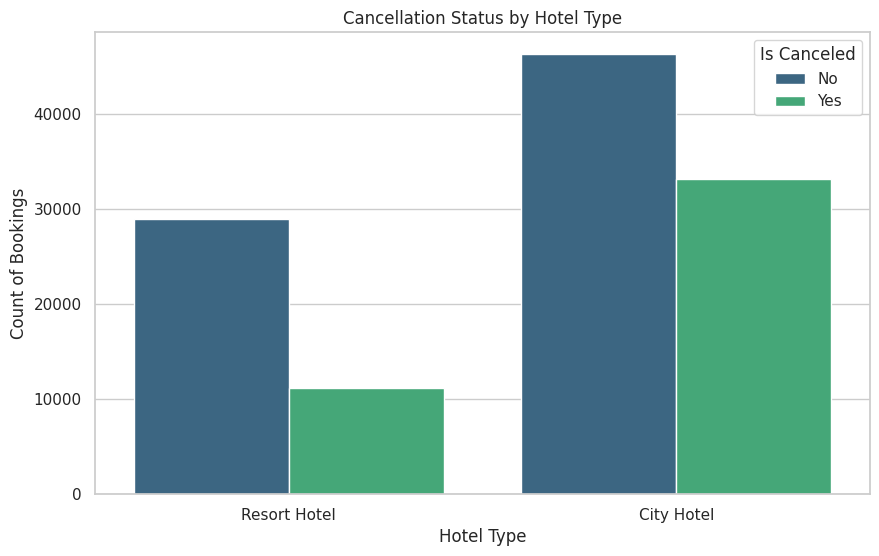

Cancellation Percentage by Hotel Type:
hotel
City Hotel      41.73%
Resort Hotel    27.76%
Name: 1, dtype: object


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='viridis')
plt.title('Cancellation Status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count of Bookings')
plt.legend(title='Is Canceled', labels=['No', 'Yes'])
plt.show()

# Calculate percentages
hotel_cancellation = df.groupby('hotel')['is_canceled'].value_counts(normalize=True).unstack() * 100
print("Cancellation Percentage by Hotel Type:")
print(hotel_cancellation[1].apply(lambda x: f'{x:.2f}%'))

Histograms illustrated the distributions of lead_time, adr, and stays_in_week_nights. Lead_time and stays_in_week_nights showed right-skewed patterns, while adr was concentrated at lower values with some higher outliers.

City Hotels showed a higher cancellation rate (41.73%) compared to Resort Hotels (27.76%), highlighting hotel type as a key factor in cancellations.

# 5. Investigating relationships between variables


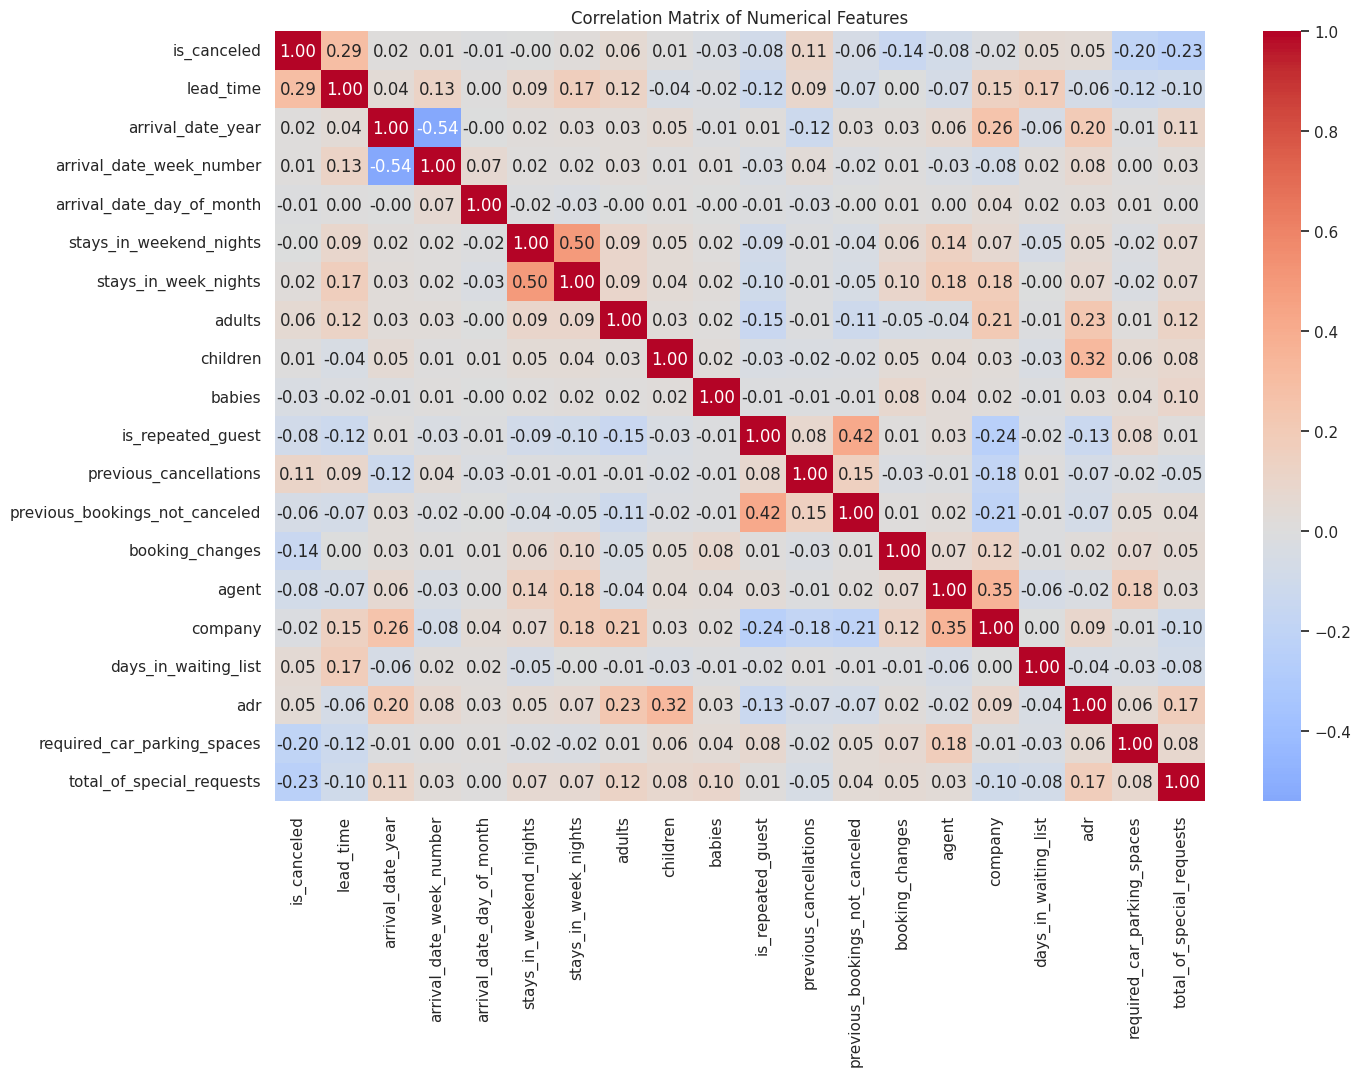

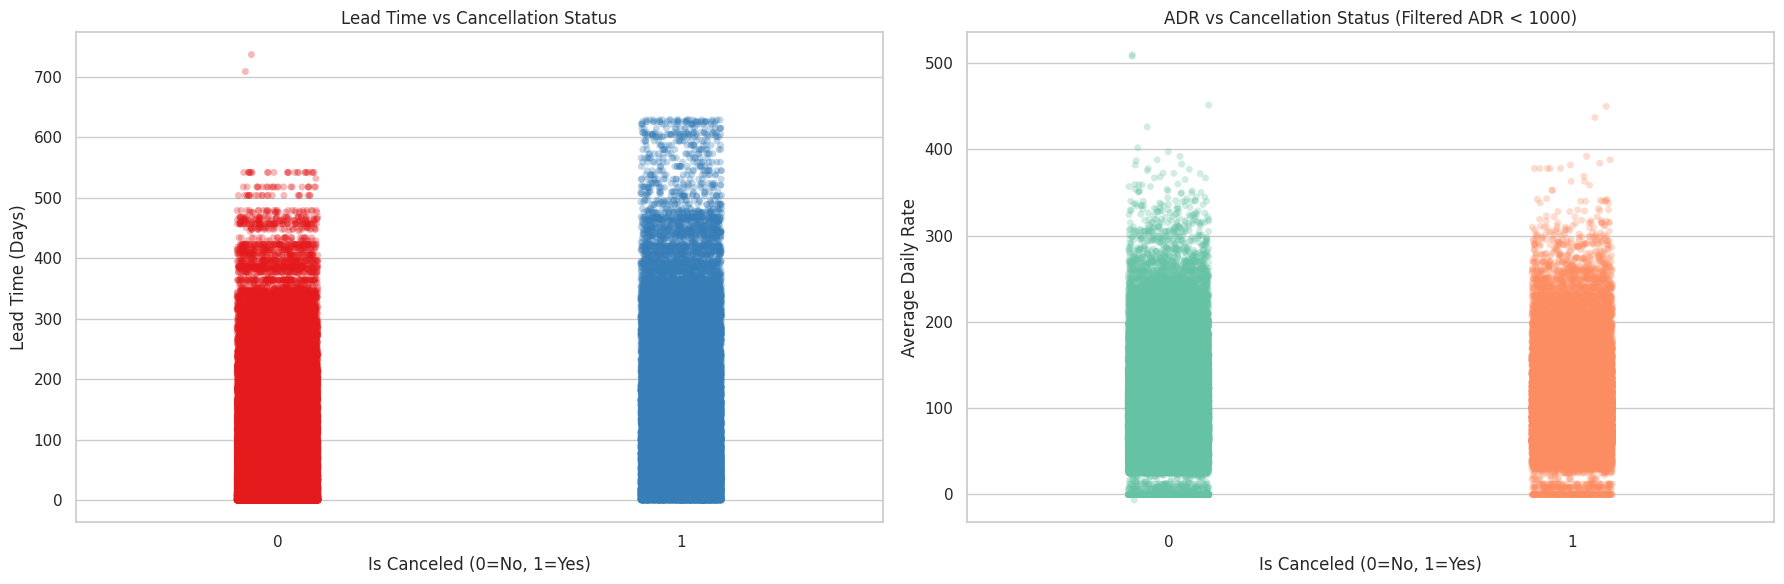

In [ ]:
# 1. Calculate correlation matrix for numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numerical_df.corr()

# 2. Visualize correlation matrix with a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 3 & 4. Specific relationship analysis using stripplots (better for categorical vs numerical)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Lead Time vs Is Canceled
sns.stripplot(data=df, x='is_canceled', y='lead_time', ax=axes[0], alpha=0.3, palette='Set1', hue='is_canceled', legend=False)
axes[0].set_title('Lead Time vs Cancellation Status')
axes[0].set_xlabel('Is Canceled (0=No, 1=Yes)')
axes[0].set_ylabel('Lead Time (Days)')

# ADR vs Is Canceled (Filtering outlier for better visibility)
sns.stripplot(data=df[df['adr'] < 1000], x='is_canceled', y='adr', ax=axes[1], alpha=0.3, palette='Set2', hue='is_canceled', legend=False)
axes[1].set_title('ADR vs Cancellation Status (Filtered ADR < 1000)')
axes[1].set_xlabel('Is Canceled (0=No, 1=Yes)')
axes[1].set_ylabel('Average Daily Rate')

plt.tight_layout()
plt.show()

The correlation matrix indicated a moderate positive relationship between lead_time and is_canceled. Stripplots visually suggested longer lead_time increased cancellation probability, while adr lacked a strong linear link but presented outliers.



# 6. Investigating relationships between variables

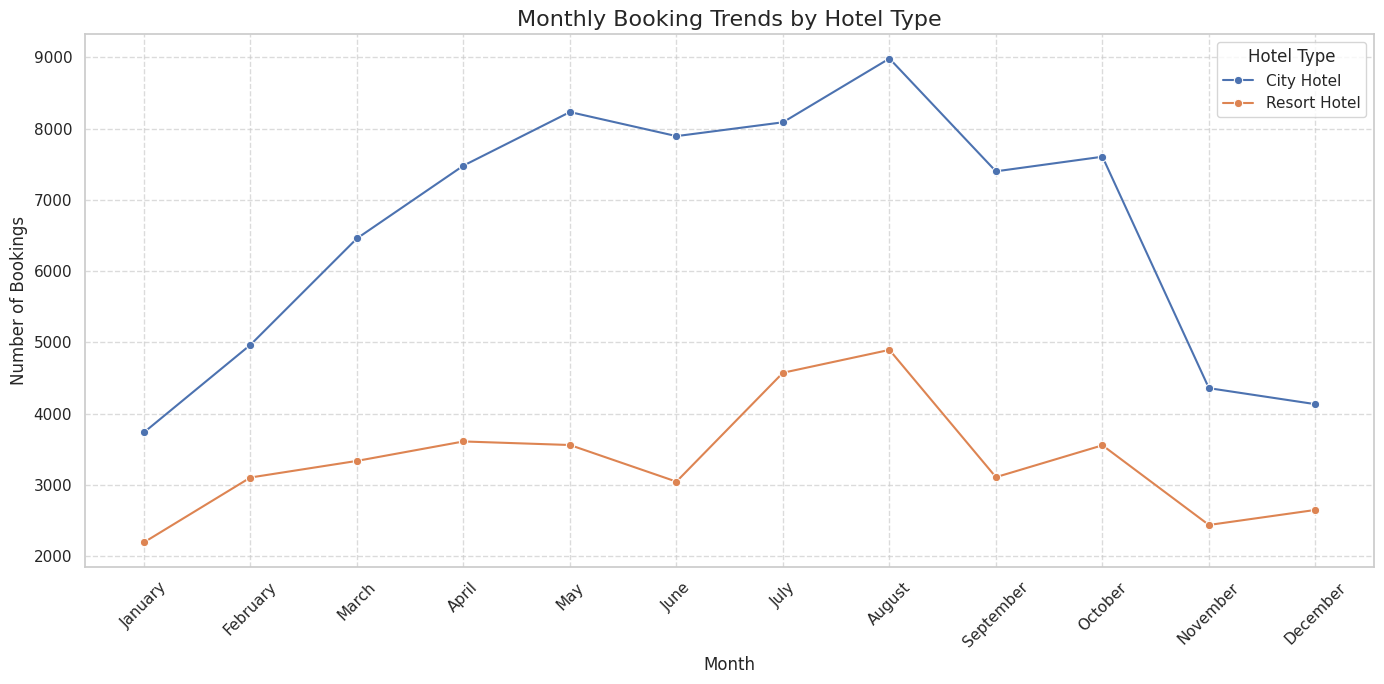

In [ ]:
# 1. Define the chronological order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# 2. Group data by month and hotel and count bookings
monthly_bookings = df.groupby(['arrival_date_month', 'hotel']).size().reset_index(name='booking_count')

# 3. Convert month column to categorical with specific order for sorting
monthly_bookings['arrival_date_month'] = pd.Categorical(monthly_bookings['arrival_date_month'], categories=month_order, ordered=True)
monthly_bookings = monthly_bookings.sort_values('arrival_date_month')

# 4. Create the line plot
plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_bookings, x='arrival_date_month', y='booking_count', hue='hotel', marker='o')

# 5. Add labels and title
plt.title('Monthly Booking Trends by Hotel Type', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Hotel Type')

# 6. Display the plot
plt.tight_layout()
plt.show()

It shows that City Hotels consistently receive a higher number of bookings throughout the year compared to Resort Hotels. Both hotel types experience a peak in bookings during the summer months, particularly in July and August, and generally lower bookings at the beginning and end of the year.

# 7. Identifying possible insights and directions for a final project


## Insights or Next Steps

Clean Missing Data: Write and execute code to handle all missing values in 'children', 'country', 'agent', and 'company'.
Revenue Risk Plot: Create a bar chart comparing the total ADR (revenue) lost to cancellations between City and Resort hotels.
Retention Timing Plot: Visualize cancellation rates over lead time to show the best window for engagement emails
